In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import sys
import os
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn.metrics
import tensorflow as tf
import tensorflow.keras as keras

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

sns.set_style('darkgrid')

In [5]:
NUMPY_DATA_FILE = '/content/drive/My Drive/AIML-ECG/data.npz'

In [6]:
thismodule = sys.modules[__name__]

with np.load(NUMPY_DATA_FILE) as data:
    for k in data.keys():
        setattr(thismodule, k, data[k].astype(float))

In [ ]:
type(Y_train)

numpy.ndarray

In [ ]:
X_train[0]

array([-0.19953837,  1.0449878 , -0.6820482 ,  0.92706519, -0.32022879,
       -0.06634729, -0.11534587])

In [ ]:
Y_train[0]

array([[-0.70352805, -0.32583401,  0.36821836, ..., -0.08259813,
        -0.13979365, -0.27325752],
       [-0.68548173, -0.30147499,  0.37402177, ..., -0.09935676,
        -0.12149201, -0.25542071],
       [-0.70954347, -0.25884673,  0.43785918, ..., -0.08930159,
        -0.10319038, -0.23758389],
       ...,
       [ 0.42737466,  0.00910246, -0.4036338 , ...,  0.08498812,
        -0.14711431, -0.1983429 ],
       [ 0.52963716,  0.03346148, -0.47327459, ...,  0.81566423,
        -0.16541594, -0.34103739],
       [ 0.14464898, -0.17967992, -0.3165828 , ...,  0.48384342,
        -0.12515233, -0.41951936]])

In [9]:
Z_train[46]

array([1., 0., 0., 0., 0.])

In [ ]:
Y_train = np.concatenate([Y_train, Y_test], axis=0)
Z_train = np.concatenate([Z_train, Z_test], axis=0)

In [ ]:
def create_Y_model(X, *, filters=(32, 64, 128), kernel_size=(5, 3, 3), strides=(1, 1, 1)):

    f1, f2, f3 = filters
    k1, k2, k3 = kernel_size
    s1, s2, s3 = strides
    X = keras.layers.Conv1D(f1, k1, strides=s1, padding='same', name='Y_conv_1')(X)
    # X = keras.layers.GRU(f1, activation='relu', return_sequences=True,  name='Y_conv_1')(X) # Added return_sequences=True for compat
    # X = keras.layers.BatchNormalization(name='Y_norm_1')(X)
    X = keras.layers.ReLU(name='Y_relu_1')(X)

    X = keras.layers.MaxPool1D(2, name='Y_pool_1')(X)
    # X = keras.layers.Dropout(0.5, name='Z_drop_1')(X)
    X = keras.layers.Conv1D(f2, k2, strides=s2, padding='same', name='Y_conv_2')(X)
    X = keras.layers.BatchNormalization(name='Y_norm_2')(X)
    X = keras.layers.ReLU(name='Y_relu_2')(X)

    X = keras.layers.MaxPool1D(2, name='Y_pool_2')(X)
    # X = keras.layers.Dropout(0.5, name='Z_drop_2')(X)
    X = keras.layers.Conv1D(f3, k3, strides=s3, padding='same', name='Y_conv_3')(X)
    # X = keras.layers.GRU(f3,activation='relu',return_sequences=True, name='Y_conv_3')(X)
    X = keras.layers.BatchNormalization(name='Y_norm_3')(X)
    X = keras.layers.ReLU(name='Y_relu_3')(X)

    X = keras.layers.GlobalAveragePooling1D(name='Y_aver')(X)
    X = keras.layers.Dropout(0.5, name='Y_drop')(X)

    return X

In [ ]:
from tensorflow import keras

def create_model02(Y_shape, Z_shape):
    Y_inputs = keras.Input(Y_shape[1:], name='Y_inputs')

    X = create_Y_model(Y_inputs, filters=(64, 128, 256), kernel_size=(7, 3, 3))
    X = keras.layers.Dense(128, activation='relu', name='Z_dense_1')(X)
    # X = keras.layers.Dropout(0.5, name='Z_drop_3')(X)
    X = keras.layers.Dense(128, activation='relu', name='Z_dense_2')(X)
    X = keras.layers.Dropout(0.5, name='Z_drop_4')(X)
    outputs = keras.layers.Dense(Z_shape[-1], activation='sigmoid', name='Z_outputs')(X)

    model = keras.Model(inputs=Y_inputs, outputs=outputs, name='model02')
    return model

In [ ]:
# model02 = create_model02(X_train.shape, Y_train.shape, Z_train.shape)
model02 = create_model02(Y_train.shape, Z_train.shape)
model02.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 'Precision', 'Recall'])
model02.summary()

Model: "model02"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Y_inputs (InputLayer)                │ (None, 1000, 12)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Y_conv_1 (Conv1D)                    │ (None, 1000, 64)            │           5,440 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Y_relu_1 (ReLU)                      │ (None, 1000, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Y_pool_1 (MaxPooling1D)              │ (None, 500, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Y_conv_2 (Conv1D)                    │ (None, 500, 128)            │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Y_norm_2 (BatchNormalization)        │ (None, 500, 128)            │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Y_relu_2 (ReLU)                      │ (None, 500, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Y_pool_2 (MaxPooling1D)              │ (None, 250, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Y_conv_3 (Conv1D)                    │ (None, 250, 256)            │          98,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Y_norm_3 (BatchNormalization)        │ (None, 250, 256)            │           1,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Y_relu_3 (ReLU)                      │ (None, 250, 256)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Y_aver (GlobalAveragePooling1D)      │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Y_drop (Dropout)                     │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Z_dense_1 (Dense)                    │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Z_dense_2 (Dense)                    │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Z_drop_4 (Dropout)                   │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Z_outputs (Dense)                    │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 180,293 (704.27 KB)

 Trainable params: 179,525 (701.27 KB)

 Non-trainable params: 768 (3.00 KB)

In [ ]:
callbacks_list = [
    keras.callbacks.EarlyStopping(monitor='val_binary_accuracy', patience=20)
    # keras.callbacks.ModelCheckpoint(filepath=MODEL_CHECKPOINT, monitor='val_binary_accuracy', save_best_only=True)
]

# history = model02.fit([X_train, Y_train], Z_train, epochs=100, batch_size=32, validation_data=([X_valid, Y_valid], Z_valid))
# history = model02.fit(Y_train, Z_train, epochs=100, batch_size=32, validation_data=(Y_valid, Z_valid))

In [ ]:
model02 = create_model02(Y_train.shape, Z_train.shape)
model02.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy', 'Precision', 'Recall'])
history = model02.fit(Y_train, Z_train, epochs=20, batch_size=16, validation_data=(Y_valid, Z_valid))

Epoch 1/20
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - Precision: 0.6393 - Recall: 0.4264 - accuracy: 0.5510 - loss: 0.4530 - val_Precision: 0.7314 - val_Recall: 0.5908 - val_accuracy: 0.6361 - val_loss: 0.3619
Epoch 2/20
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - Precision: 0.7471 - Recall: 0.6059 - accuracy: 0.6532 - loss: 0.3684 - val_Precision: 0.7420 - val_Recall: 0.5940 - val_accuracy: 0.6744 - val_loss: 0.3490
Epoch 3/20
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - Precision: 0.7690 - Recall: 0.6400 - accuracy: 0.6740 - loss: 0.3405 - val_Precision: 0.7769 - val_Recall: 0.6336 - val_accuracy: 0.6416 - val_loss: 0.3349
Epoch 4/20
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - Precision: 0.7843 - Recall: 0.6610 - accuracy: 0.6967 - loss: 0.3222 - val_Precision: 0.7786 - val_Recall: 0.6372 - val_accuracy: 0.6662 - val_loss: 0.3305
Epoch 5/20
1091/1091 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - Precision: 0.7860 - Recall: 0.6696 - accuracy: 0.6902 - loss: 0.3188 - val_Precision: 0.7786

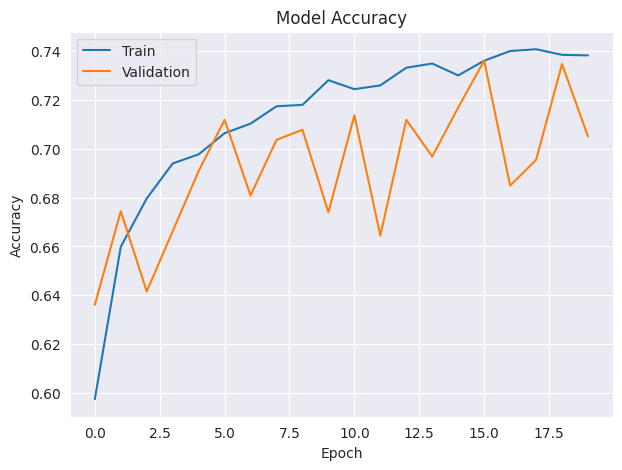

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy
plt.figure(figsize=(7, 5))
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

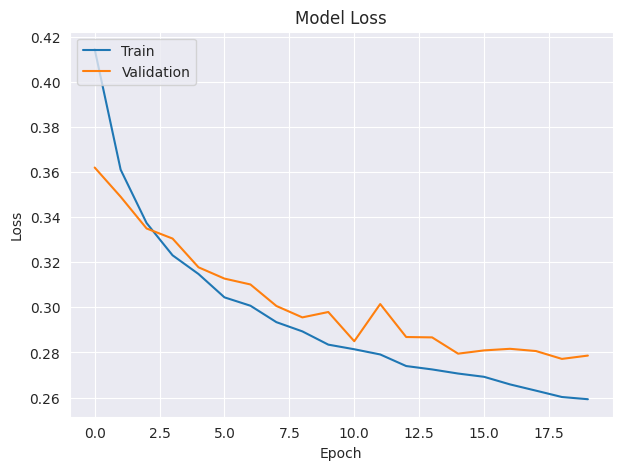

In [ ]:
# Plot training & validation loss
plt.figure(figsize=(7, 5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

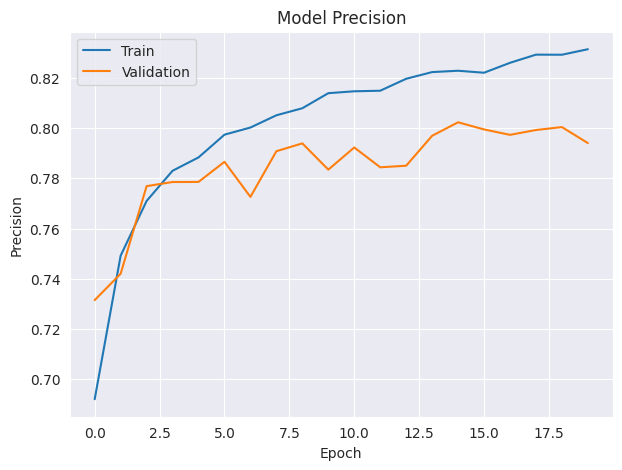

In [ ]:
# Plot training & validation precision
plt.figure(figsize=(7, 5))
plt.plot(history.history['Precision'])
plt.plot(history.history['val_Precision'])
plt.title('Model Precision')
plt.ylabel('Precision')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

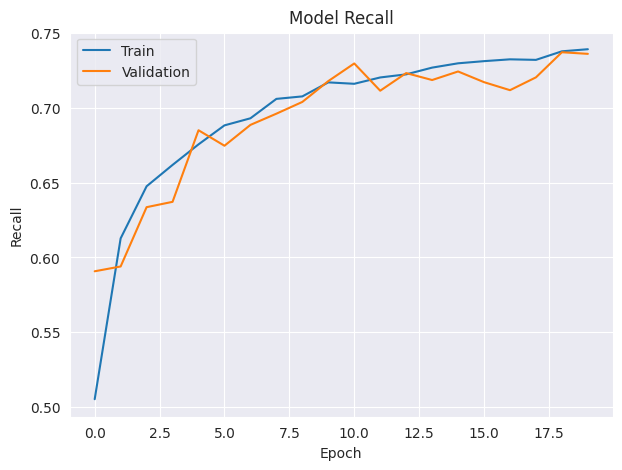

In [ ]:
# Plot training & validation recall
plt.figure(figsize=(7, 5))
plt.plot(history.history['Recall'])
plt.plot(history.history['val_Recall'])
plt.title('Model Recall')
plt.ylabel('Recall')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [ ]:
model02.evaluate(Y_test, Z_test)

69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - Precision: 0.7939 - Recall: 0.7305 - accuracy: 0.7186 - loss: 0.2742


[0.2795575261116028,
 0.7044938802719116,
 0.7875627875328064,
 0.7279543280601501]

In [ ]:
def print_confusion_matrix(confusion_matrix, axes, class_label, class_names, fontsize=14):

    df_cm = pd.DataFrame(confusion_matrix, index=class_names, columns=class_names)

    try:
        heatmap = sns.heatmap(df_cm, annot=True, fmt="d", cbar=False, ax=axes)
    except ValueError:
        raise ValueError("Confusion matrix values must be integers.")
    heatmap.yaxis.set_ticklabels(heatmap.yaxis.get_ticklabels(), rotation=0, ha='right', fontsize=fontsize)
    heatmap.xaxis.set_ticklabels(heatmap.xaxis.get_ticklabels(), rotation=45, ha='right', fontsize=fontsize)
    axes.set_ylabel('True label')
    axes.set_xlabel('Predicted label')
    axes.set_title("Class - " + class_label)

In [ ]:
labels=['NORM', 'MI', 'STTC', 'CD', 'HYP']

Z_test = Z_test.astype(int)
Z_pred = model02.predict(Y_test).round().astype(int)

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [ ]:
print(Z_pred)

[[1 0 0 0 0]
 [1 0 0 1 0]
 [1 0 0 0 0]
 ...
 [0 1 0 0 0]
 [0 0 0 1 0]
 [0 1 0 0 0]]


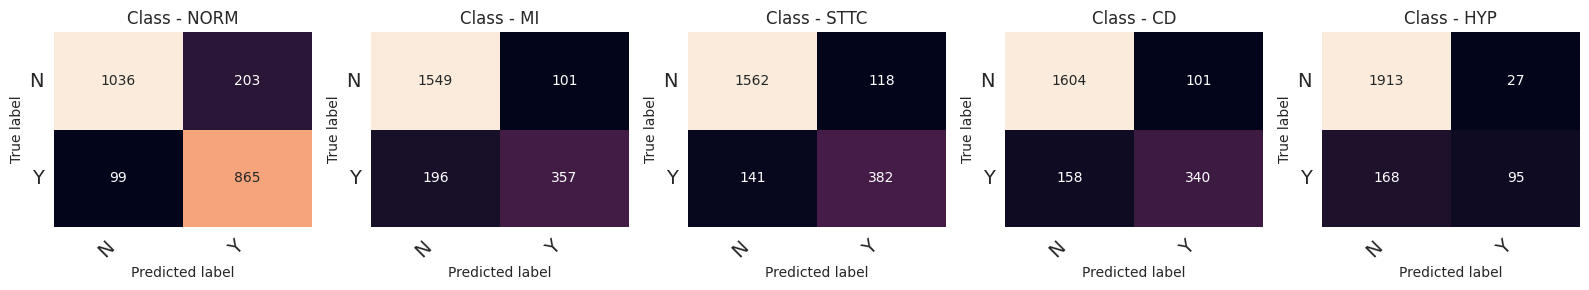

              precision    recall  f1-score   support

        NORM       0.81      0.90      0.85       964
          MI       0.78      0.65      0.71       553
        STTC       0.76      0.73      0.75       523
          CD       0.77      0.68      0.72       498
         HYP       0.78      0.36      0.49       263

   micro avg       0.79      0.73      0.76      2801
   macro avg       0.78      0.66      0.70      2801
weighted avg       0.79      0.73      0.75      2801
 samples avg       0.76      0.74      0.74      2801



In [ ]:
fig, ax = plt.subplots(1, 5, figsize=(16, 3))

for axes, cfs_matrix, label in zip(ax.flatten(), sklearn.metrics.multilabel_confusion_matrix(Z_test, Z_pred), labels):
    print_confusion_matrix(cfs_matrix, axes, label, ["N", "Y"])

fig.tight_layout()
plt.show()

print(sklearn.metrics.classification_report(Z_test, Z_pred, target_names=labels, zero_division=0))

In [ ]:
model02.save('/content/drive/My Drive/AIML-ECG/model02.h5')

# Backend Code

In [2]:
!pip install wfdb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.3/162.3 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 85.8 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.2.3 which is incompatible.


In [3]:
import wfdb
import pandas as pd

# Specify the record name and path (without file extension)
record_name = "00045_lr"  # Replace with your actual file name (without .dat/.hea)
path = "/content/drive/My Drive/AIML-ECG/"   # Replace with the actual path

# Load the ECG signal and metadata
record = wfdb.rdrecord(f"{path}/{record_name}")
signals, fields = wfdb.rdsamp(f"{path}/{record_name}")

# Convert to DataFrame
df = pd.DataFrame(signals, columns=fields['sig_name'])

# Save as CSV
csv_path = f"{path}/{record_name}.csv"
df.to_csv(csv_path, index=False)

print(f"CSV saved at: {csv_path}")

CSV saved at: /content/drive/My Drive/AIML-ECG//00045_lr.csv


In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
def load_ecg_csv(csv_ecg):
  ecg_data = np.loadtxt(csv_ecg, delimiter=",", skiprows=1)
  # Define lead names for a 12-lead ECG
  lead_names = ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]

  # Create a figure with 12 subplots (one per lead)
  fig, axes = plt.subplots(nrows=12, ncols=1, figsize=(10, 15), sharex=True)

  # Plot each lead
  for i in range(12):
      axes[i].plot(ecg_data[:, i], label=f"Lead {lead_names[i]}", color="black")
      axes[i].legend(loc="upper right")
      axes[i].set_ylabel("mV")

  axes[-1].set_xlabel("Time (samples)")
  plt.suptitle("12-Lead ECG")
  plt.tight_layout()
  plt.show()

  Y_scaler = StandardScaler()
  Y_scaler.fit(ecg_data.reshape(-1, ecg_data.shape[-1]))
  ecg_data = Y_scaler.transform(ecg_data.reshape(-1, ecg_data.shape[-1])).reshape(ecg_data.shape)

  return ecg_data

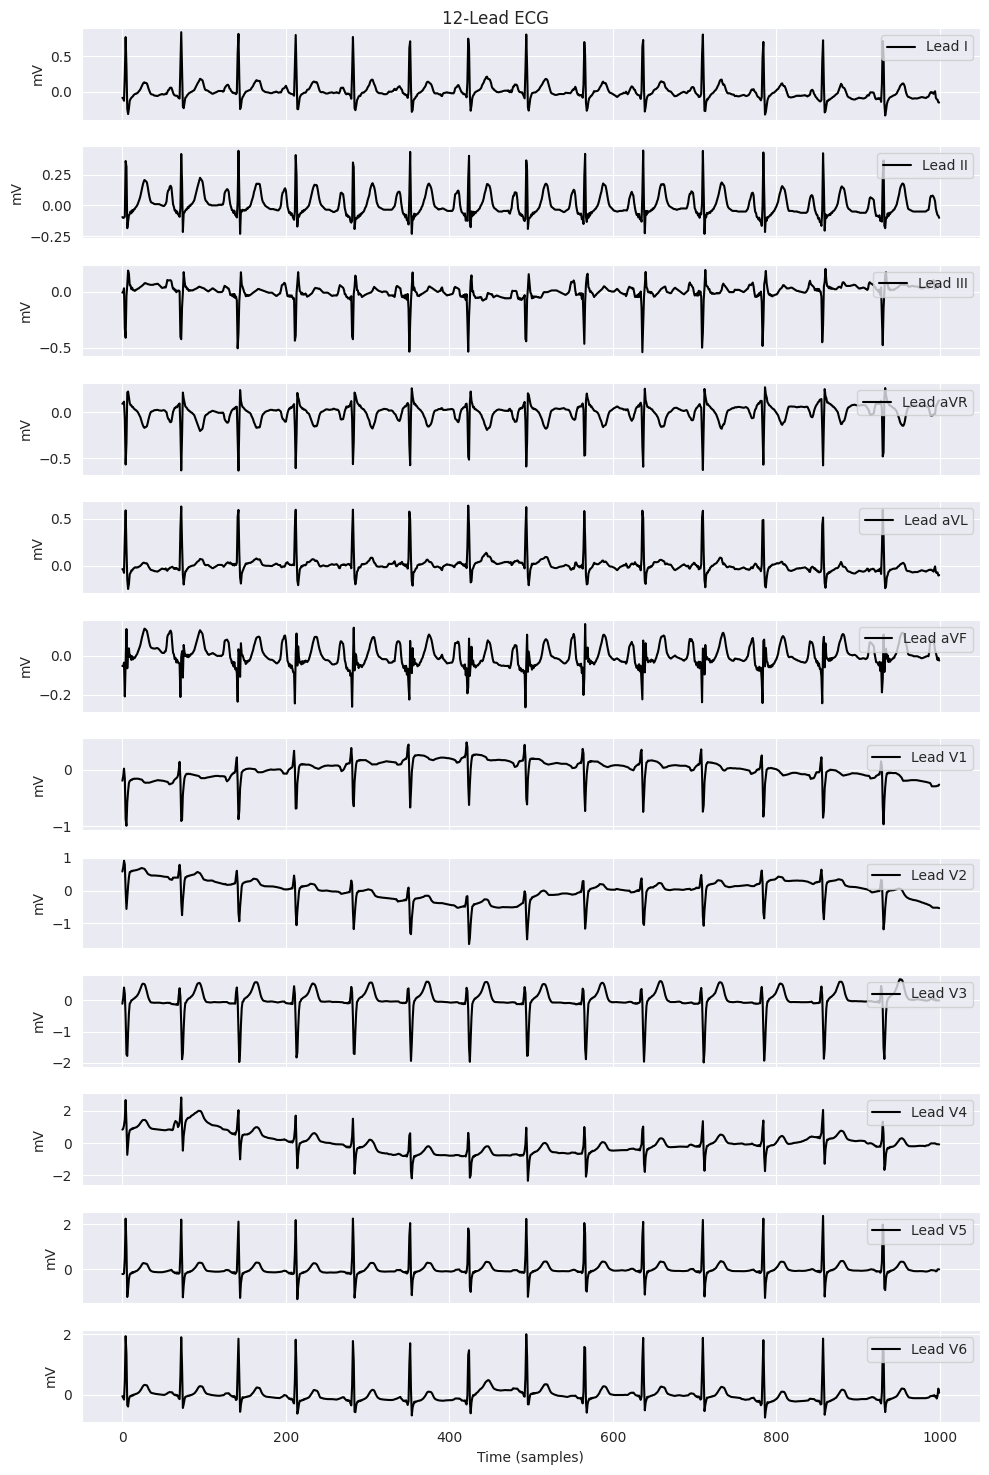

In [ ]:
your_csv_ecg = load_ecg_csv(csv_ecg='/content/drive/My Drive/AIML-ECG/08005_lr.csv')

In [ ]:
your_csv_ecg.shape

(1000, 12)

In [ ]:
type(your_csv_ecg)

numpy.ndarray

In [ ]:
model = tf.keras.models.load_model('/content/drive/My Drive/AIML-ECG/model02.h5')
model.summary()

Model: "model02"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ Y_inputs (InputLayer)                │ (None, 1000, 12)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Y_conv_1 (Conv1D)                    │ (None, 1000, 64)            │           5,440 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Y_relu_1 (ReLU)                      │ (None, 1000, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Y_pool_1 (MaxPooling1D)              │ (None, 500, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Y_conv_2 (Conv1D)                    │ (None, 500, 128)            │          24,704 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Y_norm_2 (BatchNormalization)        │ (None, 500, 128)            │             512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Y_relu_2 (ReLU)                      │ (None, 500, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Y_pool_2 (MaxPooling1D)              │ (None, 250, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Y_conv_3 (Conv1D)                    │ (None, 250, 256)            │          98,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Y_norm_3 (BatchNormalization)        │ (None, 250, 256)            │           1,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Y_relu_3 (ReLU)                      │ (None, 250, 256)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Y_aver (GlobalAveragePooling1D)      │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Y_drop (Dropout)                     │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Z_dense_1 (Dense)                    │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Z_dense_2 (Dense)                    │ (None, 128)                 │          16,512 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Z_drop_4 (Dropout)                   │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ Z_outputs (Dense)                    │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 180,295 (704.28 KB)

 Trainable params: 179,525 (701.27 KB)

 Non-trainable params: 768 (3.00 KB)

 Optimizer params: 2 (12.00 B)

In [ ]:
your_csv_ecg = your_csv_ecg.reshape(1, your_csv_ecg.shape[0], your_csv_ecg.shape[1])
prediction = model.predict(your_csv_ecg).round().astype(int)
print("Prediction:", prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Prediction: [[0 1 0 0 0]]
